# Hafta 6 · Ders 12 — Bir CNN'i Eğitmek (Bitirme Projesi)

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Final. Geçen derste inşa ettiğimiz katmanı küçük bir **evrişimli sinir ağına** yığıyoruz, gerçek
elle yazılmış rakamları sınıflandırmak için baştan sona eğitiyoruz ve **öğrendiği filtreleri
görselleştiriyoruz** — sonra onları ta Hafta 3'ün elle tasarlanmış kenar dedektörlerine kadar geri
izliyoruz.

Bu notebook'un iki bölümü var:

- **Bölüm A — saf NumPy.** Burada eğitilen, her gradyanı elle türetilmiş, tamamen sıfırdan bir CNN.
  Bu, kavrayış.
- **Bölüm B — PyTorch.** Ölçeklemek istediğinizde, birkaç satır PyTorch ile aynı mimari. (`torch`
  kurulu bir ortamda çalıştırın — o bölümdeki nota bakın.)

Döngüyü kapatıyoruz: "bir görüntü bir dizidir" (Ders 1)'den eğitilmiş bir tanıyıcıya.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from utils.cv_utils import show, show_row, check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# Bölüm A — NumPy'da sıfırdan bir CNN

## 1. Veri: elle yazılmış rakamlar

Klasik 8×8 rakamlar veri kümesini kullanıyoruz — sıfırdan bir CNN'i saniyeler içinde eğitmek için
yeterince küçük, gerçek bir tanıma görevi olacak kadar gerçek. Her örnek, 0–9 arasında bir rakamın
8×8 gri tonlamalı bir görüntüsüdür.

images: (1797, 8, 8)  labels: (1797,)  classes: [0 1 2 3 4 5 6 7 8 9]


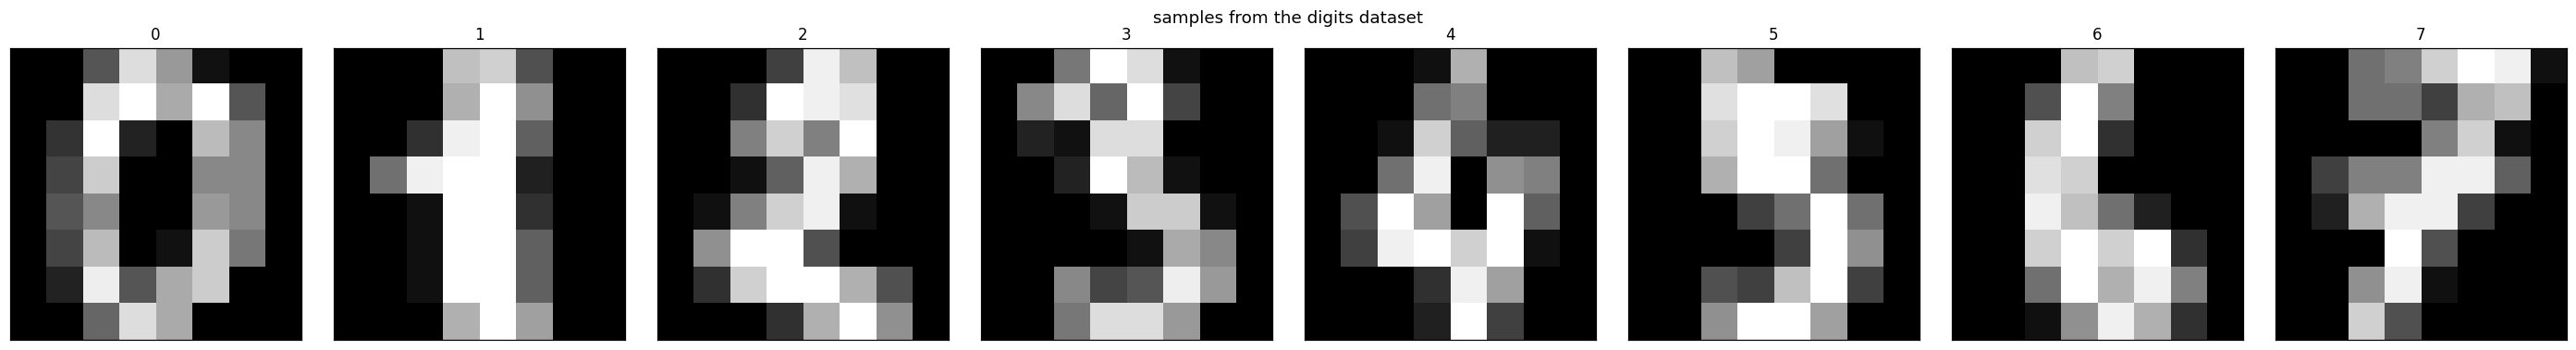

train: 1400  test: 397


In [2]:
digits = load_digits()
X = digits.images.astype(float) / 16.0      # [0, 1] aralığına normalize et
y = digits.target
print("görüntüler:", X.shape, " etiketler:", y.shape, " sınıflar:", np.unique(y))

show_row([X[i] for i in range(8)], [str(y[i]) for i in range(8)])
plt.suptitle("rakam veri kümesinden örnekler", y=1.06); plt.show()

# eğitim/test ayrımı
rng = np.random.default_rng(0)
idx = rng.permutation(len(X))
ntr = 1400
tr, te = idx[:ntr], idx[ntr:]
Xtr, ytr, Xte, yte = X[tr], y[tr], X[te], y[te]
print("eğitim:", len(Xtr), " test:", len(Xte))

## 2. Katmanlar

Ders 11'deki işlemleri yeniden kullanıyoruz — evrişim (çapraz korelasyon), ReLU, maks-havuzlama — ve
sınıflandırma için bir **tam bağlantılı (fully-connected)** katman ile bir **softmax + çapraz entropi**
kaybı ekliyoruz. Her birinin ileri ve geri geçişi var. Mimari kasıtlı olarak küçük: tek bir evrişim
katmanı (birkaç filtre) → ReLU → havuzlama → düzleştir → doğrusal → softmax.

In [3]:
# --- çok filtreli evrişim (ileri/geri), filtreler üzerinde vektörleştirilmiş ---
def conv_forward(X, W, b):
    # X: (H, Wd)  W: (F, k, k)  b: (F,)  ->  Y: (F, H-k+1, Wd-k+1)
    F, k, _ = W.shape
    H, Wd = X.shape
    oh, ow = H-k+1, Wd-k+1
    Y = np.zeros((F, oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = X[i:i+k, j:j+k]
            Y[:, i, j] = np.sum(patch[None] * W, axis=(1, 2)) + b
    return Y

def conv_backward(dY, X, W):
    F, k, _ = W.shape
    oh, ow = dY.shape[1:]
    dW = np.zeros_like(W); dX = np.zeros_like(X); db = dY.sum(axis=(1, 2))
    for i in range(oh):
        for j in range(ow):
            patch = X[i:i+k, j:j+k]
            for f in range(F):
                dW[f] += dY[f, i, j] * patch
                dX[i:i+k, j:j+k] += dY[f, i, j] * W[f]
    return dX, dW, db

def relu_f(X): return np.maximum(0, X), (X > 0)
def relu_b(dY, m): return dY * m

def maxpool_f(X, s=2):
    F, H, W = X.shape
    oh, ow = H//s, W//s
    Y = np.zeros((F, oh, ow)); arg = {}
    for f in range(F):
        for i in range(oh):
            for j in range(ow):
                win = X[f, i*s:(i+1)*s, j*s:(j+1)*s]
                Y[f, i, j] = win.max()
                a = np.unravel_index(win.argmax(), win.shape)
                arg[(f, i, j)] = (f, i*s+a[0], j*s+a[1])
    return Y, arg

def maxpool_b(dY, arg, shape):
    dX = np.zeros(shape)
    for key, src in arg.items():
        dX[src] += dY[key]
    return dX

def softmax_ce(scores, label):
    z = scores - scores.max()
    p = np.exp(z) / np.exp(z).sum()
    loss = -np.log(p[label] + 1e-12)
    dscores = p.copy(); dscores[label] -= 1
    return loss, dscores, p
print("katmanlar tanımlandı.")

layers defined.


## 3. Ağ: ileri, geri ve bir eğitim adımı

Katmanları, geri geçişin ihtiyaç duyduğu her şeyi döndüren tek bir ileri geçişe bağlıyoruz, ardından
her parametre için gradyanlar üreten bir geri geçişe. Düz bir SGD güncellemesi döngüyü kapatır.
Tasarımı küçük, ama *tam* bir CNN — otomatik türev yok, her gradyan bizim.

In [4]:
class TinyCNN:
    def __init__(self, n_filters=6, k=3, pool=2, n_classes=10, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.standard_normal((n_filters, k, k)) * 0.2
        self.b = np.zeros(n_filters)
        # evrişim sonrası (8-k+1=6) → havuzlama//2 = 3 → düzleştir = F*3*3
        conv_out = 8 - k + 1
        pooled = conv_out // pool
        self.fc_in = n_filters * pooled * pooled
        self.Wfc = rng.standard_normal((n_classes, self.fc_in)) * (1/np.sqrt(self.fc_in))
        self.bfc = np.zeros(n_classes)
        self.pool = pool

    def forward(self, x):
        cache = {"x": x}
        z = conv_forward(x, self.W, self.b);      cache["z"] = z
        a, m = relu_f(z);                          cache["m"] = m
        p, arg = maxpool_f(a, self.pool);          cache["arg"] = arg; cache["a_shape"] = a.shape
        flat = p.ravel();                          cache["p_shape"] = p.shape; cache["flat"] = flat
        scores = self.Wfc @ flat + self.bfc
        return scores, cache

    def backward(self, dscores, cache):
        dWfc = np.outer(dscores, cache["flat"])
        dbfc = dscores
        dflat = self.Wfc.T @ dscores
        dp = dflat.reshape(cache["p_shape"])
        da = maxpool_b(dp, cache["arg"], cache["a_shape"])
        dz = relu_b(da, cache["m"])
        _, dW, db = conv_backward(dz, cache["x"], self.W)
        return dW, db, dWfc, dbfc

    def step(self, grads, lr):
        dW, db, dWfc, dbfc = grads
        self.W -= lr*dW; self.b -= lr*db; self.Wfc -= lr*dWfc; self.bfc -= lr*dbfc

net = TinyCNN()
s, cache = net.forward(Xtr[0])
print("ileri çıkış (sınıf skorları):", s.round(2))

forward output (class scores): [-0.34 -0.43  0.   -0.66 -0.24 -0.01  0.22 -0.16  0.03 -0.3 ]


### Tüm ağ üzerinde gradyan kontrolü

Eğitmeden önce, bir parametrenin uçtan uca gradyanını sonlu farklara karşı doğrula. Eşleşirse, her
katmanın geri geçişi doğru biçimde birleşiyor demektir.

In [5]:
def net_loss(net, x, label):
    scores, _ = net.forward(x)
    loss, _, _ = softmax_ce(scores, label)
    return loss

x0, l0 = Xtr[0], ytr[0]
scores, cache = net.forward(x0)
_, dscores, _ = softmax_ce(scores, l0)
dW, db, dWfc, dbfc = net.backward(dscores, cache)

# bir evrişim ağırlığını sayısal olarak kontrol et
eps = 1e-5
i, j, kk = 0, 1, 1
net.W[i, j, kk] += eps; lp = net_loss(net, x0, l0)
net.W[i, j, kk] -= 2*eps; lm = net_loss(net, x0, l0)
net.W[i, j, kk] += eps
num = (lp - lm) / (2*eps)
check("uçtan uca evrişim-ağırlığı gradyanı", dW[i, j, kk], num, atol=1e-4)

[PASS] end-to-end conv-weight gradient    max|Δ| = 3.65e-13


True

## 4. Ağı eğit

Eğitim kümesi üzerinde mini-yığın SGD çalıştırıyor, kayıp ve test doğruluğunu takip ediyoruz. 8×8
rakamlarda bu küçük CNN birkaç dönemde (epoch) yüksek doğruluğa ulaşır — tamamen türettiğimiz NumPy
gradyanlarıyla eğitilmiş olarak.

epoch 1/6  loss=0.820  test_acc=0.892


epoch 2/6  loss=0.251  test_acc=0.950


epoch 3/6  loss=0.179  test_acc=0.952


epoch 4/6  loss=0.159  test_acc=0.960


epoch 5/6  loss=0.120  test_acc=0.972


epoch 6/6  loss=0.100  test_acc=0.967


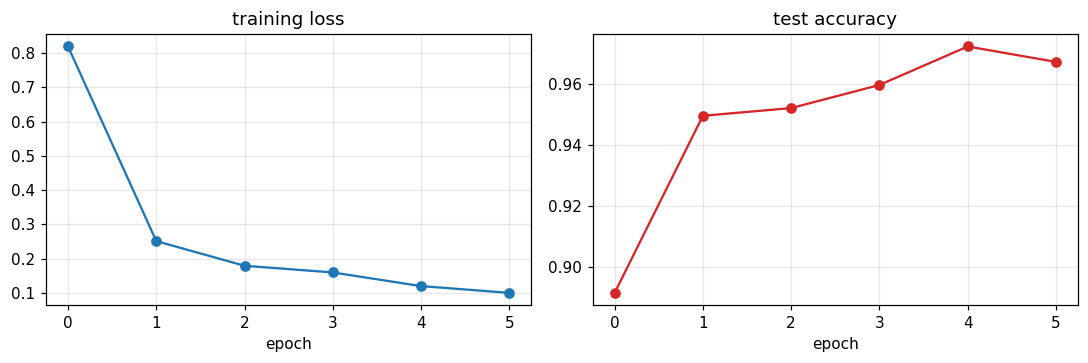

In [6]:
def accuracy(net, X, y):
    correct = 0
    for x, label in zip(X, y):
        scores, _ = net.forward(x)
        correct += (scores.argmax() == label)
    return correct / len(y)

net = TinyCNN(n_filters=6, seed=1)
lr = 0.05
epochs = 6
losses, accs = [], []
order = np.arange(len(Xtr))
for ep in range(epochs):
    rng.shuffle(order)
    ep_loss = 0.0
    for idx_i in order:
        x, label = Xtr[idx_i], ytr[idx_i]
        scores, cache = net.forward(x)
        loss, dscores, _ = softmax_ce(scores, label)
        ep_loss += loss
        net.step(net.backward(dscores, cache), lr)
    losses.append(ep_loss / len(Xtr))
    accs.append(accuracy(net, Xte, yte))
    print(f"dönem {ep+1}/{epochs}  kayıp={losses[-1]:.3f}  test_doğr={accs[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(losses, "o-", color="C0"); ax[0].set_title("eğitim kaybı"); ax[0].set_xlabel("dönem"); ax[0].grid(alpha=0.3)
ax[1].plot(accs, "o-", color="C3"); ax[1].set_title("test doğruluğu"); ax[1].set_xlabel("dönem"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Öğrenilen filtreleri görselleştirme — tüm kursun ödülü

İşte her şeyin bağlandığı an. Evrişim filtrelerini *rastgele gürültüden* gradyan inişiyle eğittik.
Şimdi onları gösteriyoruz — ve **Hafta 3'te elle tasarladığımız Sobel filtrelerine** güçlü biçimde
benzeyen yönelimli, kenar-benzeri çekirdekler buluyoruz. Ağ, yalnızca veriden, kenarların doğru
düşük-seviye öznitelikler olduğunu *yeniden keşfetti*.

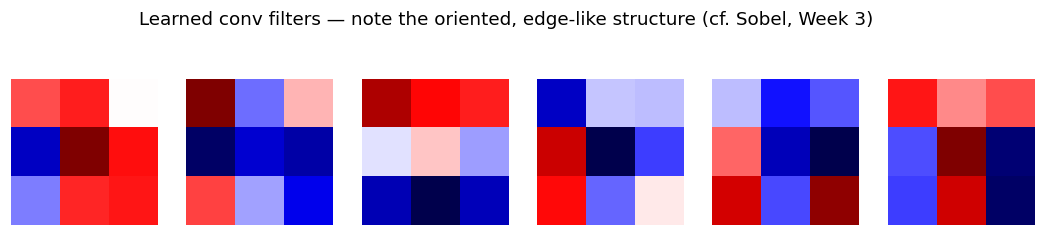

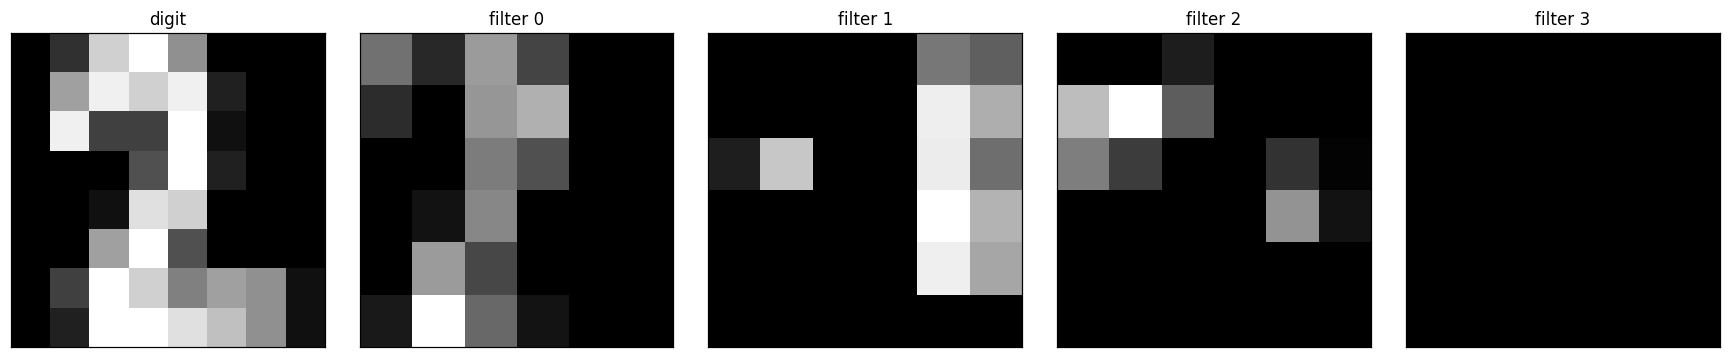

In [7]:
fig, axes = plt.subplots(1, len(net.W), figsize=(2*len(net.W), 2.2))
for ax, f in zip(axes, net.W):
    ax.imshow(f, cmap="seismic", vmin=-np.abs(f).max(), vmax=np.abs(f).max())
    ax.axis("off")
plt.suptitle("Öğrenilen evrişim filtreleri — yönelimli, kenar-benzeri yapıya dikkat (krş. Sobel, Hafta 3)", y=1.08)
plt.show()

# öğrenilen bir filtrenin bir rakama ne yaptığını göster
xd = Xte[0]
resp = conv_forward(xd, net.W, net.b)
show_row([xd] + [np.maximum(0, resp[f]) for f in range(min(4, len(resp)))],
         ["rakam"] + [f"filtre {f}" for f in range(min(4, len(resp)))])
plt.show()

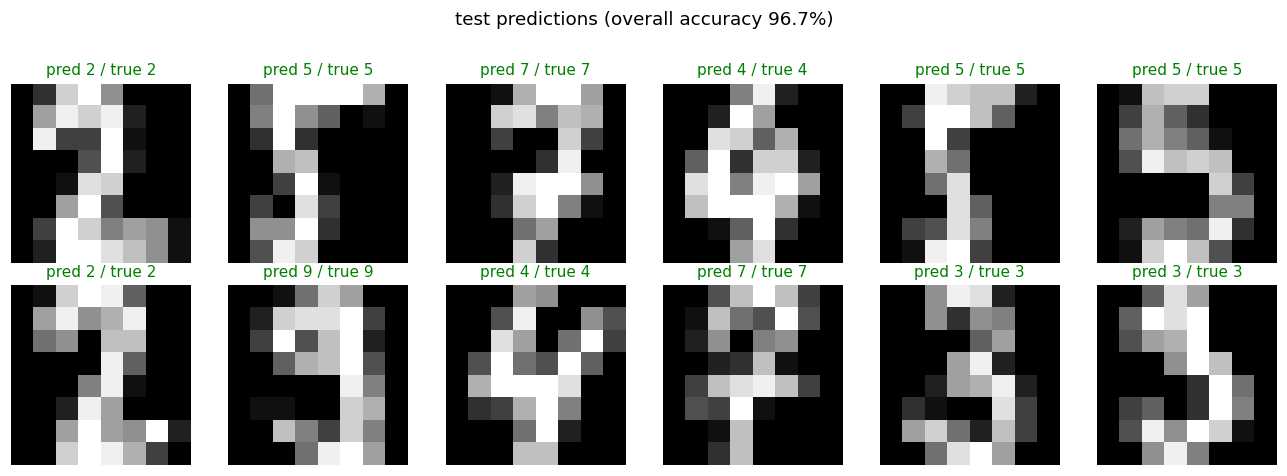

In [8]:
# karışıklık önizlemesi: birkaç test tahmini
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for ax, i in zip(axes.ravel(), range(12)):
    scores, _ = net.forward(Xte[i])
    pred = scores.argmax()
    ax.imshow(Xte[i], cmap="gray"); ax.axis("off")
    ax.set_title(f"tahmin {pred} / gerçek {yte[i]}", color=("green" if pred == yte[i] else "red"), fontsize=10)
plt.suptitle(f"test tahminleri (genel doğruluk {accuracy(net, Xte, yte):.1%})", y=1.02)
plt.tight_layout(); plt.show()

# Bölüm B — Aynı CNN, PyTorch'ta

Yukarıdakilerin hepsi saf NumPy idi, böylece hiçbir şey gizli değildi. Pratikte, optimize edilmiş,
yığınlanmış, GPU-hızlandırmalı evrişimler ve **otomatik türev (automatic differentiation)** sağlayan
bir çerçeve kullanırsınız — böylece yalnızca ileri geçişi yazarsınız ve gradyanlar bedavaya gelir.

> **Not:** aşağıdaki hücre `torch` gerektirir. Kurulu değilse,
> `pip install torch --index-url https://download.pytorch.org/whl/cpu` ile kurun ve yeniden çalıştırın.
> Kod, torch eksikse zarif biçimde indirgenecek şekilde yazılmıştır (hata vermek yerine bir mesaj
> yazdırır), dolayısıyla notebook onsuz da baştan sona çalışır.

In [9]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

    # aynı mimari: evrişim(6, 3x3) → ReLU → maks-havuzlama(2) → doğrusal → 10 sınıf
    class TorchCNN(nn.Module):
        def __init__(self, n_filters=6, n_classes=10):
            super().__init__()
            self.conv = nn.Conv2d(1, n_filters, kernel_size=3)   # 8→6
            self.pool = nn.MaxPool2d(2)                          # 6→3
            self.fc = nn.Linear(n_filters * 3 * 3, n_classes)
        def forward(self, x):
            x = self.pool(F.relu(self.conv(x)))
            return self.fc(x.flatten(1))

    # tensörler
    Xt = torch.tensor(X[:, None, :, :], dtype=torch.float32)     # (N,1,8,8)
    yt = torch.tensor(y, dtype=torch.long)
    Xtr_t, ytr_t = Xt[tr], yt[tr]
    Xte_t, yte_t = Xt[te], yt[te]

    model = TorchCNN()
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    lossf = nn.CrossEntropyLoss()

    for ep in range(6):
        model.train()
        perm = torch.randperm(len(Xtr_t))
        for i in range(0, len(perm), 64):
            b = perm[i:i+64]
            opt.zero_grad()
            out = model(Xtr_t[b])
            loss = lossf(out, ytr_t[b])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            acc = (model(Xte_t).argmax(1) == yte_t).float().mean().item()
        print(f"[torch] dönem {ep+1}/6  test_doğr={acc:.3f}")
    print("\nAynı mimari, ~aynı doğruluk — ama otomatik türev tüm geri geçişleri bizim için yazdı.")
except ImportError:
    print("PyTorch bu ortamda kurulu değil.")
    print("Kurun (yukarıdaki nota bakın) ve çerçeve versiyonunu eğitmek için bu hücreyi yeniden çalıştırın.")
    print("Bölüm A'daki saf-NumPy ağı zaten tüm mekanizmayı gösteriyor.")

PyTorch is not installed in this environment.
Install it (see the note above) and re-run this cell to train the framework version.
The pure-NumPy network in Part A already demonstrates the full mechanism.


## Bunun modern görüde nerede karşımıza çıktığı

İnşa ettiğiniz şey doğrudan gerçek olana ölçeklenir:

- Bu evrişim→ReLU→havuzlama bloklarının **daha derin yığınları**, tam olarak klasik mimarilerdir
  (LeNet, AlexNet, VGG). Daha fazla filtre, daha fazla katman, daha büyük görüntüler — aynı işlemler.
- **Otomatik türev** (Bölüm B), gerçek çerçevelerin buradaki matematiğe eklediği tek şeydir: ileri
  geçişi yazarsınız, elle türettiğiniz geri geçişler otomatik olarak üretilir.
- **Transfer öğrenme, tespit, bölütleme**, hepsi bu notebook'un ölçeklenmiş ve ön-eğitilmiş hali olan
  evrişimli bir *omurga (backbone)* üzerine inşa edilir — ve onun ilk katman filtreleri hâlâ §5'te
  gördüğünüz kenar dedektörlerine benzer.

Artık görü yığınını pikselden eğitilmiş bir ağa kadar — ve her katmanının neden o şekilde göründüğünü —
anlıyorsunuz.

## Alıştırmalar (bitirme projesi uzantıları)

1. **Daha fazla filtre.** NumPy CNN'inde `n_filters`'ı artır ve doğruluğa ve öğrenilen filtre bankasına etkisini gözlemle.
2. **İki evrişim katmanı.** `TinyCNN`'e ikinci bir evrişim→ReLU→havuzlama bloğu ekle ve biçimleri yeniden türet. Derinlik bu küçük veri kümesinde yardımcı oluyor mu?
3. **Karışıklık matrisi.** Test kümesinde 10×10 bir karışıklık matrisi inşa et ve hangi rakam çiftlerinin en sık karıştırıldığını belirle. Onu görsel benzerliklerine bağla.

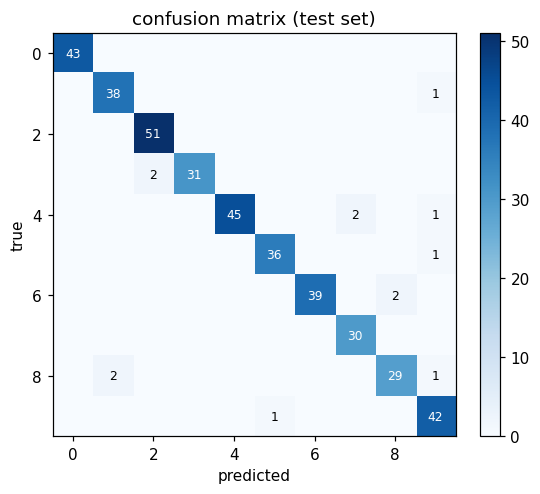

off-diagonal entries show the most-confused digit pairs.


In [10]:
# === Çözümler (önce kendiniz deneyin!) ===

# 3. karışıklık matrisi
conf = np.zeros((10, 10), int)
for x, label in zip(Xte, yte):
    pred = net.forward(x)[0].argmax()
    conf[label, pred] += 1
plt.figure(figsize=(5.2, 4.6))
plt.imshow(conf, cmap="Blues")
for i in range(10):
    for j in range(10):
        if conf[i, j]:
            plt.text(j, i, conf[i, j], ha="center", va="center",
                     color="white" if conf[i, j] > conf.max()/2 else "black", fontsize=8)
plt.xlabel("tahmin"); plt.ylabel("gerçek"); plt.title("karışıklık matrisi (test kümesi)")
plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()
print("köşegen dışı girişler en çok karıştırılan rakam çiftlerini gösterir.")

## Kurs özeti — neleri inşa ettiniz

Altı hafta boyunca bilgisayarlı görüyü **piksellerden derin ağlara** kadar elle inşa ettiniz:

- **Hafta 1:** diziler olarak görüntüler, nokta işlemleri, histogramlar.
- **Hafta 2:** sıfırdan evrişim ve Gauss/ölçek-uzayı.
- **Hafta 3:** gradyanlar, Sobel ve tam Canny kenar dedektörü.
- **Hafta 4:** Harris köşeleri (bir özdeğer problemi), damlalar, betimleyiciler ve eşleştirme.
- **Hafta 5:** k-ortalamalar ve Hough bölütlemesi ve Lucas–Kanade optik akış.
- **Hafta 6:** elle türetilmiş geri yayılımlı bir evrişim katmanı ve baştan sona eğitilmiş bir CNN —
  öğrenilen filtreleri Hafta-3'ün kenar dedektörlerini yeniden keşfetti.

Sadece bir görü kütüphanesini nasıl çağıracağınızı değil, her işlemin *neyi* hesapladığını, *neden*
çalıştığını ve klasik fikirlerin *nasıl* derin olanlara dönüştüğünü biliyorsunuz. Kalıcı olan kısım,
o anlayıştır.

---
*Bilgisayarlı Görü · Hafta 6 · Ders 12 · Kurs sonu*